In [16]:
import numpy as np
import os, path
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [17]:
data_format = "decimal"
DATASET_FOLDER_PATH = os.path.join(os.getcwd(), r"dataset\decimal")



BENIGN_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_benign.csv")
DOS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_DoS.csv")
SPOOFING_GAS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-GAS.csv")
SPOOFING_RPM_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-RPM.csv")
SPOOFING_SPEED_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-SPEED.csv")
SPOOFING_STEERING_WHEEL_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-STEERING_WHEEL.csv")


assert os.path.isfile(BENIGN_DATASET_PATH) & \
    os.path.isfile(DOS_DATASET_PATH) & \
        os.path.isfile(SPOOFING_GAS_DATASET_PATH) & \
            os.path.isfile(SPOOFING_RPM_DATASET_PATH) & \
                os.path.isfile(SPOOFING_SPEED_DATASET_PATH) & \
                    os.path.isfile(SPOOFING_STEERING_WHEEL_DATASET_PATH)

In [18]:
benign_df = pd.read_csv(BENIGN_DATASET_PATH)
dos_df = pd.read_csv(DOS_DATASET_PATH)
spf_gas_df = pd.read_csv(SPOOFING_GAS_DATASET_PATH)
spf_rpm_df = pd.read_csv(SPOOFING_RPM_DATASET_PATH)
spf_speed_df = pd.read_csv(SPOOFING_SPEED_DATASET_PATH)
spf_str_wheel_df = pd.read_csv(SPOOFING_STEERING_WHEEL_DATASET_PATH)



print(f"Length of all benign is {len(benign_df)}")
print(f"Length of all dos is {len(dos_df)}")
print(f"Length of all spoof gas is {len(spf_gas_df)}")
print(f"Length of all spoof rpm is {len(spf_rpm_df)}")
print(f"Length of all spoof speed is {len(spf_speed_df)}")
print(f"Length of all spoof steering wheel is {len(spf_str_wheel_df)}")

Length of all benign is 1223737
Length of all dos is 74663
Length of all spoof gas is 9991
Length of all spoof rpm is 54900
Length of all spoof speed is 24951
Length of all spoof steering wheel is 19977


In [19]:
big_df = pd.concat((benign_df, dos_df, spf_gas_df, spf_rpm_df, spf_speed_df, spf_str_wheel_df), axis=0)

print(f"Length of the new combined dataset is {len(big_df)}")
big_df.head()

Length of the new combined dataset is 1408219


,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class
0,65,96,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
1,1068,132,13,160,0,0,0,0,0,BENIGN,BENIGN,BENIGN
2,535,127,255,127,255,127,255,127,255,BENIGN,BENIGN,BENIGN
3,131,15,224,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
4,936,1,0,39,16,0,0,0,0,BENIGN,BENIGN,BENIGN


In [20]:
# Train test split

label_col = 'label'
category_col = 'category'
class_col = 'specific_class'
CID_col = "ID"

seed = 42

# Predict attack type
y = big_df[class_col]

# Remove labels to prevent leakage
x = big_df.drop(columns=[label_col, category_col, class_col, CID_col])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=seed, shuffle=True)

print(f"Data split into {len(x_train)} for training and {len(x_test)} for testing")

print("\nClass distribution:")
print(y_train.value_counts())

Data split into 985753 for training and 422466 for testing

Class distribution:
specific_class
BENIGN            856615
DoS                52264
RPM                38430
SPEED              17466
STEERING_WHEEL     13984
GAS                 6994
Name: count, dtype: int64


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
from sklearn.preprocessing import LabelEncoder

le_encoder = LabelEncoder()

y_train = le_encoder.fit_transform(y_train)
y_test = le_encoder.transform(y_test)

In [23]:
import xgboost as xgb
import time


xgb_model = xgb.XGBClassifier(n_estimators=10)

start_time = time.time()

xgb_model.fit(x_train_scaled, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")
print(f"Classes learned: {len(xgb_model.classes_)}")
print(xgb_model.classes_)

Training completed in 5.44 seconds
Classes learned: 6
[0 1 2 3 4 5]


In [24]:
y_pred = xgb_model.predict(x_test_scaled)

y_pred = le_encoder.inverse_transform(y_pred)
y_test = le_encoder.inverse_transform(y_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=6))

Accuracy : 0.996409
Precision: 0.996710
Recall   : 0.996409
F1 Score : 0.996286

Classification Report
                precision    recall  f1-score   support

        BENIGN   0.999989  1.000000  0.999995    367122
           DoS   1.000000  1.000000  1.000000     22399
           GAS   1.000000  1.000000  1.000000      2997
           RPM   0.915860  0.999939  0.956055     16470
         SPEED   1.000000  0.797862  0.887568      7485
STEERING_WHEEL   1.000000  0.999499  0.999750      5993

      accuracy                       0.996409    422466
     macro avg   0.985975  0.966217  0.973894    422466
  weighted avg   0.996710  0.996409  0.996286    422466



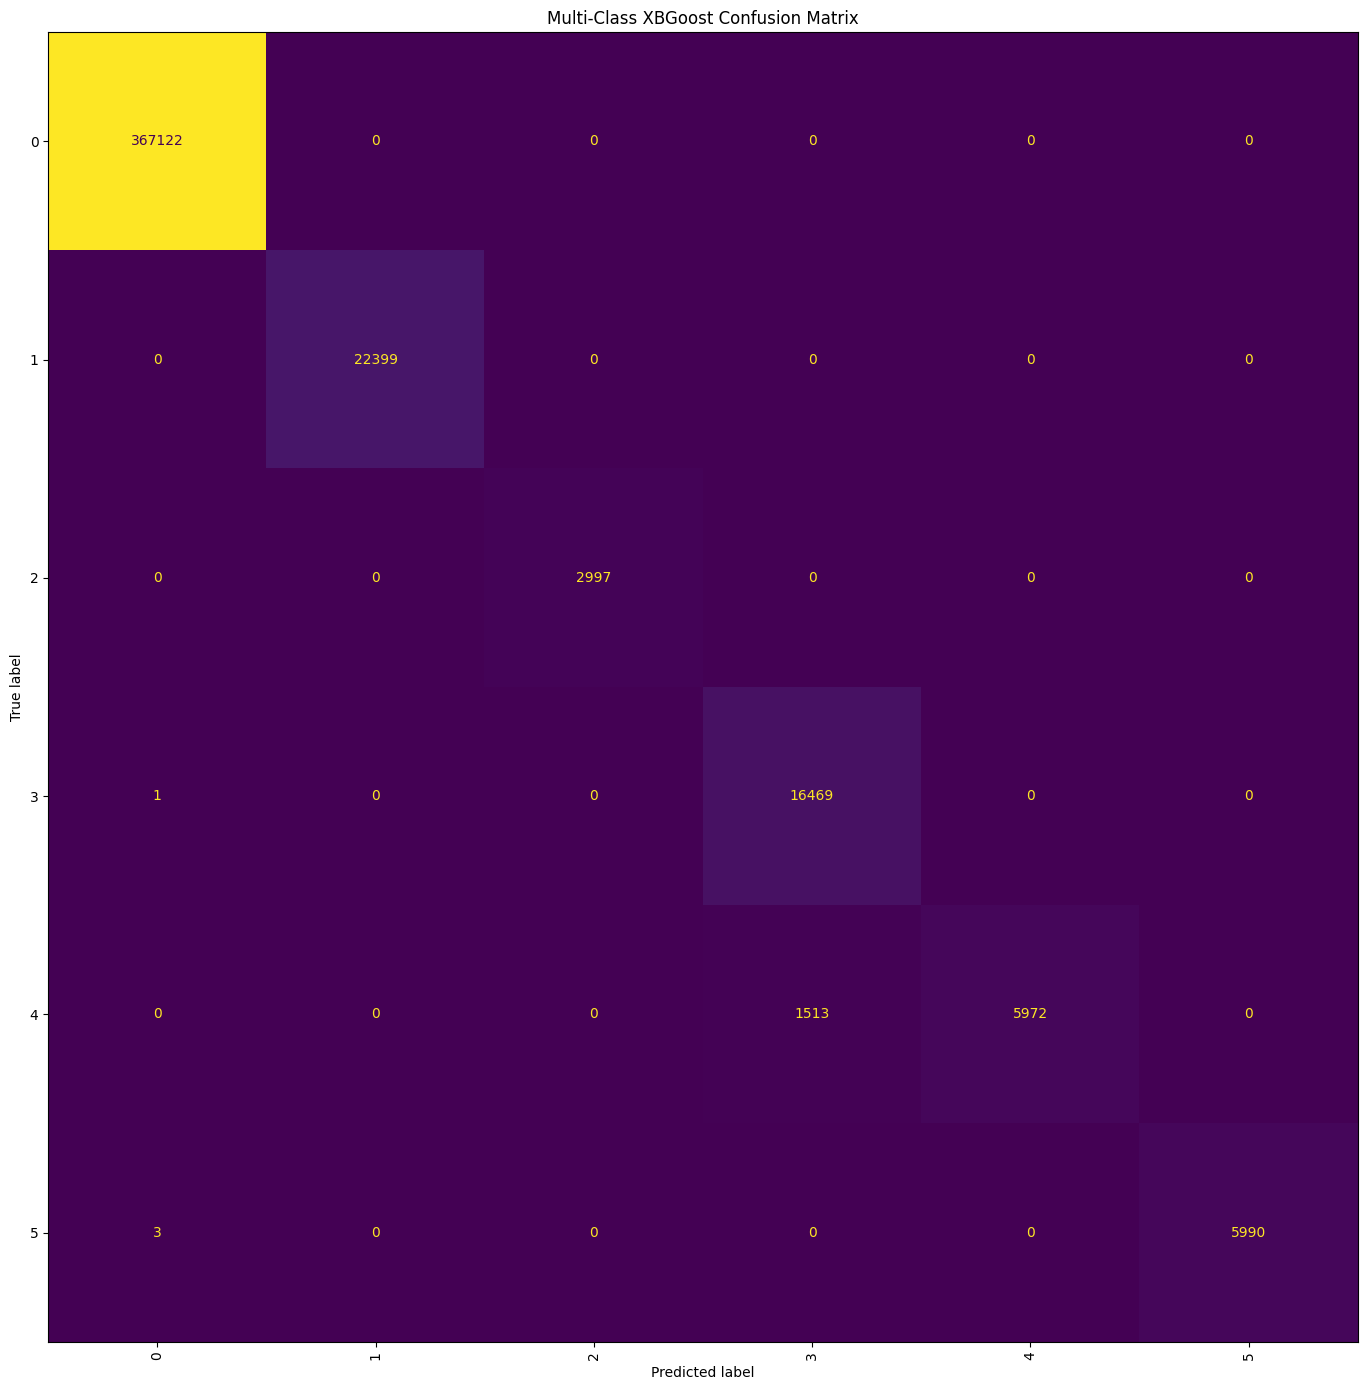

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)

disp.plot( ax=ax, xticks_rotation=90, colorbar=False)

plt.title("Multi-Class XBGoost Confusion Matrix")
plt.tight_layout()
plt.show()

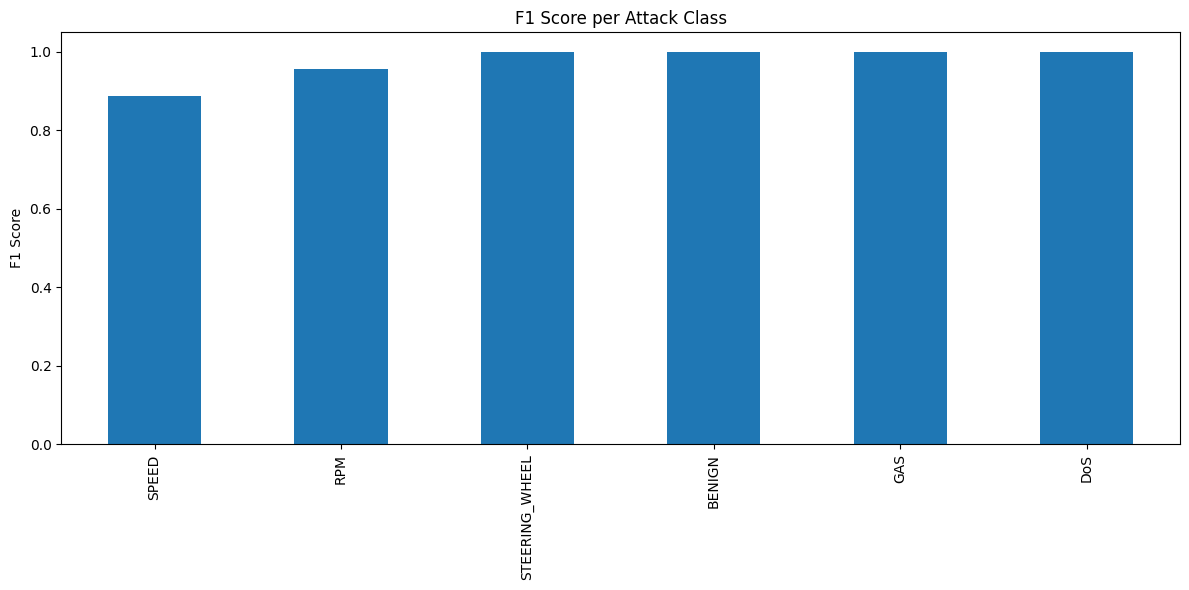

In [27]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(y_test, y_pred, output_dict=True)
 
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.iloc[:-3]

plt.figure(figsize=(12, 6))
class_metrics['f1-score'].sort_values().plot(kind='bar')

plt.title("F1 Score per Attack Class")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

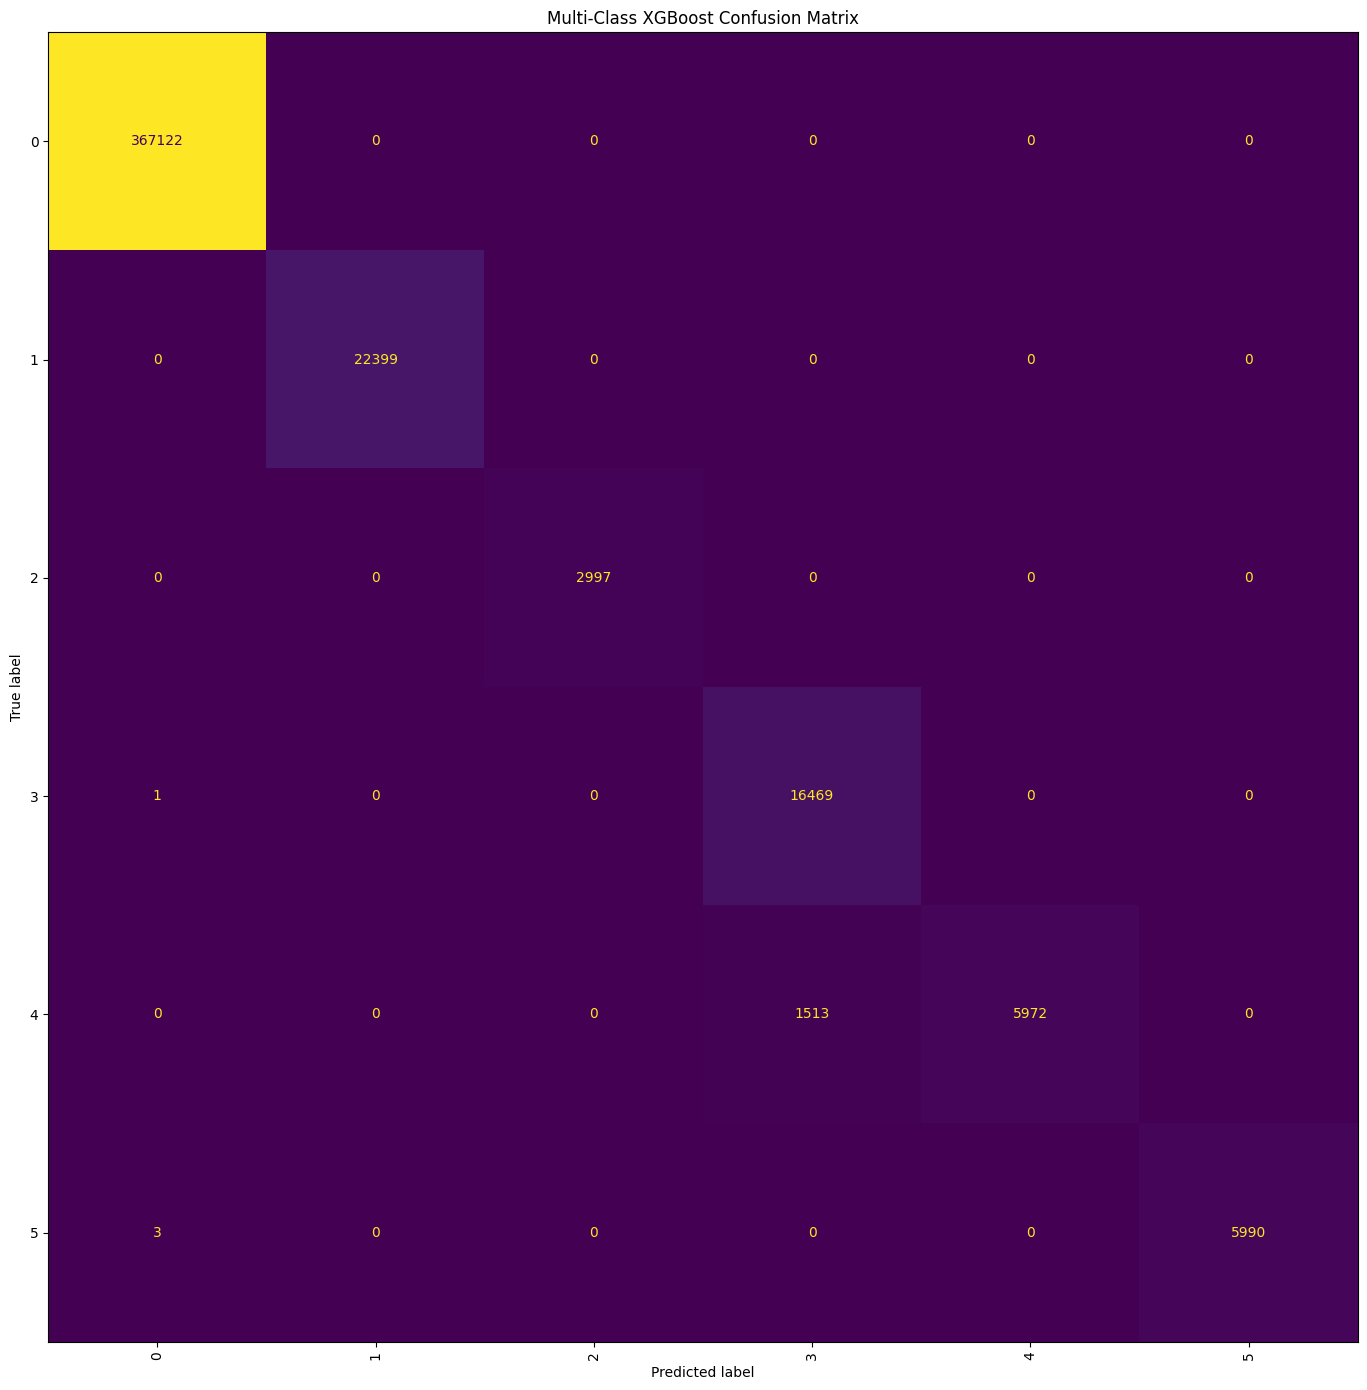

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)

disp.plot( ax=ax, xticks_rotation=90, colorbar=False)

plt.title("Multi-Class XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

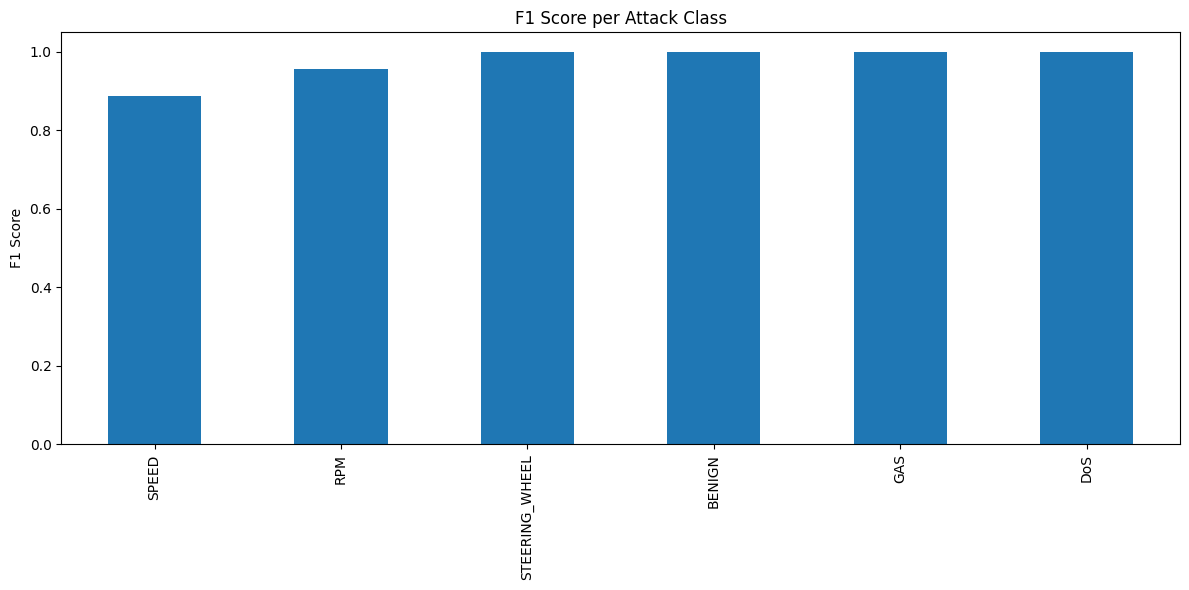

In [29]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(y_test, y_pred, output_dict=True)
 
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.iloc[:-3]

plt.figure(figsize=(12, 6))
class_metrics['f1-score'].sort_values().plot(kind='bar')

plt.title("F1 Score per Attack Class")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

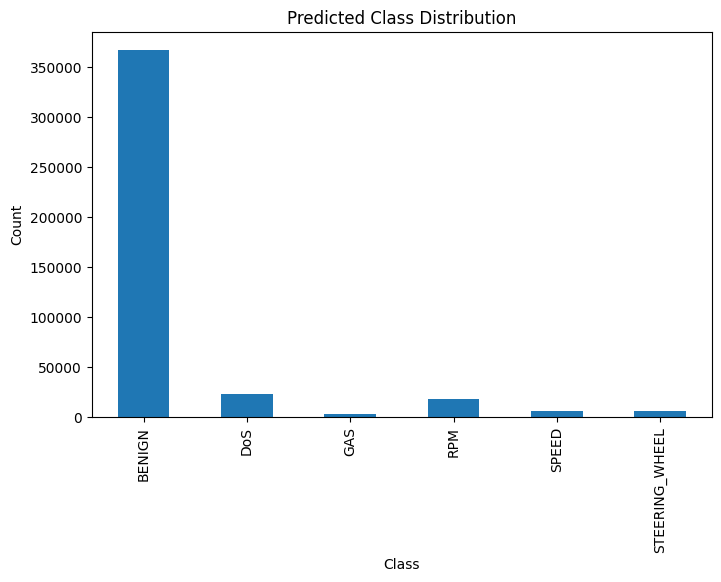

BENIGN            367126
DoS                22399
GAS                 2997
RPM                17982
SPEED               5972
STEERING_WHEEL      5990
Name: count, dtype: int64


In [30]:
import pandas as pd

pred_counts = pd.Series(y_pred).value_counts().sort_index()

plt.figure(figsize=(8, 5))
pred_counts.plot(kind='bar')

plt.title("Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(pred_counts)